# 01. 미들웨어 기초 (Middleware Basics)

> 미들웨어는 에이전트 실행 흐름의 정해진 **훅(Hook) 지점**에 로직을 끼워 넣는 구조예요. 여기서 훅은 “모델 호출 직전/직후”, “모델·도구 호출을 감싸는 순간”처럼 런타임이 우리 코드를 자동으로 불러주는 약속된 확장 지점이에요. 데코레이터·클래스 두 가지 작성법을 모두 익혀요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. 미들웨어(Middleware)의 개념과 에이전트 실행 흐름에서의 역할을 설명할 수 있어요
2. 대표적인 내장(Built-in) 미들웨어 6종을 상황에 맞게 선택하고 적용할 수 있어요
3. 데코레이터 기반과 클래스 기반으로 커스텀 미들웨어를 직접 구현할 수 있어요
4. 여러 미들웨어를 조합할 때 실행 순서(before/after/wrap)를 예측하고 제어할 수 있어요

## 사전 지식

- Part 05 `01-Create-Agent.ipynb`: `@before_model`/`@after_model`, `@dynamic_prompt` 맛보기
- Part 05 `05-Runtime-Context.ipynb`: Runtime 객체와 context 전달 방법
- `create_agent` 함수 사용법과 AgentState 구조
- LangChain V1 도구(Tool) 정의 방법

## 미들웨어란?

미들웨어(Middleware)는 에이전트의 핵심 실행 루프에 **끼어들어** 로직을 삽입하는 방법이에요.

> 🔑 **핵심 개념**: 미들웨어를 **공항 보안검색대**에 비유할 수 있어요. 탑승객(요청)은 공항(에이전트)에 들어오면 보안검색대(미들웨어)를 순서대로 통과해요. 각 검색대에서는 신분확인(인증), 소지품 검사(PII 필터), 짐 크기 제한(호출 제한) 등을 수행하고, 모든 검사를 통과해야 비행기(모델)에 탈 수 있어요.

핵심 에이전트 루프는 이렇게 동작해요:
1. 모델을 호출해요
2. 모델이 도구 실행을 선택하면 도구를 실행해요
3. 더 이상 도구를 호출하지 않으면 종료해요

미들웨어는 이 각 단계의 **전후**에 커스텀 로직을 삽입할 수 있어요.

### 먼저 용어 정리: 훅(Hook)

훅은 실행 엔진이 정해진 순간에 개발자 코드를 “걸어 두었다가” 자동으로 호출해주는 확장 지점이에요. 일반 함수 호출은 우리가 직접 `my_func()`를 부르지만, 훅은 `create_agent`가 모델 호출 직전, 모델 응답 직후, 도구 호출을 감싸는 순간에 등록된 함수를 대신 호출해줘요.

Part 05에서 `@before_model`/`@after_model`, `@dynamic_prompt`를 맛보기로 봤다면, 이 노트북에서는 그 아이디어를 전체 지도 위에 올려놓는 단계예요. LangChain 미들웨어의 핵심 훅은 **노드 스타일 4개**와 **랩 스타일 2개**로 나뉘고, `@dynamic_prompt`는 자주 쓰이는 편의 데코레이터로 따로 기억하면 좋아요.

- **노드 스타일**: 흐름의 특정 지점에서 순서대로 실행되고, 필요하면 `dict`를 반환해 state를 업데이트해요.
- **랩 스타일**: 모델/도구 호출을 함수처럼 감싸고, `handler`를 0번·1번·여러 번 호출해 재시도, 캐싱, 폴백 같은 제어 흐름을 만들 수 있어요.

```mermaid
flowchart LR
    subgraph MW["미들웨어 실행 흐름"]
        direction LR
        BA[before_agent] --> BM[before_model]
        BM --> WM[wrap_model_call]
        WM --> M[모델 호출]
        M --> AM[after_model]
        AM --> T{도구 호출?}
        T -- Yes --> WT[wrap_tool_call]
        WT --> BM
        T -- No --> AA[after_agent]
    end

    classDef hook fill:#cce5ff,stroke:#007bff,color:#004085
    classDef model fill:#d4edda,stroke:#28a745,color:#155724
    classDef tool fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef decision fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class BA,BM,AM,AA,WM hook
    class M model
    class WT tool
    class T decision
```

### 미들웨어가 할 수 있는 것

| 역할 | 설명 | 예시 |
|------|------|------|
| **모니터링** | 로깅, 분석, 디버깅 | 호출 횟수 추적, 응답 시간 기록 |
| **수정** | 프롬프트, 도구 선택, 출력 변환 | 동적 시스템 프롬프트, 응답 후처리 |
| **제어** | 재시도, 폴백, 조기 종료 | 실패 시 자동 재시도, 대체 모델 전환 |
| **강제** | 속도 제한, 가드레일, PII 감지 | 호출 횟수 제한, 민감 정보 마스킹 |

### 훅(Hook) 종류: 노드 스타일 vs 랩 스타일

| 훅 | 스타일 | 실행 시점 | 비유 |
|------|--------|----------|------|
| `before_agent` | 노드 | 에이전트 시작 전 (호출당 1번) | 공항 입구 보안검색 |
| `before_model` | 노드 | 각 모델 호출 전 | 탑승구 앞 마지막 검사 |
| `after_model` | 노드 | 각 모델 응답 후 | 도착 후 세관 검사 |
| `after_agent` | 노드 | 에이전트 완료 후 (호출당 최대 1번) | 공항 출구 |
| `wrap_model_call` | 랩 | 모델 호출을 감싸서 완전 제어 | 비행기 기장 (이/착륙 결정) |
| `wrap_tool_call` | 랩 | 도구 호출을 감싸서 완전 제어 | 화물 관리자 (적재 여부 결정) |

> 💡 **실무 팁**: 노드 스타일(before/after)은 실행 흐름에 끼어드는 방식이고, 랩 스타일(wrap)은 실행 자체를 제어하는 방식이에요. 랩 스타일에서는 핸들러 호출 여부, 횟수, 시점을 완전히 결정할 수 있어요.

## 환경 설정

In [39]:
# 환경 변수 로드 (.env 파일에서 API 키 등을 읽어와요)
from dotenv import load_dotenv

load_dotenv()

True

In [40]:
# ---------------------------------------------------
# 기본 도구와 모델 설정
# ---------------------------------------------------
# V1 API: langchain.tools, langchain.chat_models, langchain.agents 사용
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain.agents import create_agent


# 실습용 간단한 날씨 도구 정의
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    # 실제 API 대신 더미 데이터 반환 (실습용)
    weather_data = {
        "서울": "맑음, 23도",
        "부산": "흐림, 19도",
        "Tokyo": "Sunny, 25C",
        "Seoul": "Clear, 23C",
    }
    return weather_data.get(city, f"It's sunny in {city}! (더미 데이터)")


# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 변경 가능: "anthropic:claude-sonnet-4-5", "ollama:llama3"
model = init_chat_model("openai:gpt-4o-mini")

# 모델과 도구 설정 완료!
print(f"모델: gpt-4o-mini")
print(f"도구: {get_weather.name} - {get_weather.description}")

모델: gpt-4o-mini
도구: get_weather - Get the current weather for a given city.


## 1. 미들웨어 없는 기본 에이전트

먼저 미들웨어 없는 기본 에이전트를 만들어볼게요. `create_agent`의 `middleware` 파라미터에 빈 리스트를 전달해요.

> 💡 **핵심 정리**: `middleware=[]`는 기본값과 동일해요. 이후 단계에서 이 리스트에 미들웨어를 하나씩 추가하면서 변화를 관찰할 거예요.

In [41]:
# ---------------------------------------------------
# 기본 에이전트 생성 (미들웨어 없음)
# ---------------------------------------------------
from langchain_core.runnables import RunnableConfig

# create_agent: V1 API의 에이전트 생성 함수
# middleware 파라미터에 빈 리스트 = 미들웨어 없음
basic_agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[],  # 여기에 미들웨어를 추가할 거예요
)

# 에이전트 실행
result = basic_agent.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨 알려줘"}]},
    config=RunnableConfig(),
)

# 마지막 메시지(AI 응답) 출력
print("에이전트 응답:", result["messages"][-1].content)

에이전트 응답: 현재 서울의 날씨는 맑고, 기온은 23도입니다.


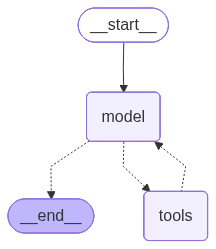

In [42]:
from IPython.display import Image, display
basic_agent

## 2. 내장(Built-in) 미들웨어

LangChain V1은 자주 쓰이는 패턴을 위한 내장 미들웨어를 여러 개 제공해요 (현재 공식 문서 기준 10종 이상). 이 노트북에서는 그중 **대표적인 6가지**를 먼저 살펴볼게요. 전체 목록과 세부 옵션은 `04-Prebuilt-Middleware.ipynb`에서 다뤄요.

| 미들웨어 | 역할 | 주요 파라미터 |
|---------|------|-------------|
| `SummarizationMiddleware` | 대화 길어지면 자동 요약 | `model`, `trigger`, `keep` |
| `ModelCallLimitMiddleware` | 모델 호출 횟수 제한 | `thread_limit`, `run_limit`, `exit_behavior` |
| `ToolCallLimitMiddleware` | 도구 호출 횟수 제한 | `tool_name`, `thread_limit`, `run_limit` |
| `ModelFallbackMiddleware` | 실패 시 대체 모델 전환 | 대체 모델 목록 |
| `PIIMiddleware` | 개인정보(PII) 감지/처리 | `pii_type`, `strategy`, `detector` |
| `ToolRetryMiddleware` | 도구 실패 시 재시도 | `max_retries`, `backoff_factor`, `jitter` |

> 💡 **참고**: 이외에도 `ModelRetryMiddleware`, `LLMToolSelectorMiddleware`, `TodoListMiddleware`, `ContextEditingMiddleware`, `HumanInTheLoopMiddleware` 등이 제공돼요. 모두 `langchain.agents.middleware`에서 import 할 수 있어요.

### 2-1. 대화 요약 (SummarizationMiddleware)

대화가 길어지면 토큰 한도에 도달할 수 있어요. `SummarizationMiddleware`는 대화 기록이 특정 토큰 수를 초과할 때 자동으로 요약해요.

> 💡 **실무 팁**: `trigger=("tokens", 4000)`처럼 토큰 수로 트리거하거나 `trigger=("messages", 20)`처럼 메시지 수로 트리거할 수 있어요. 프로덕션에서는 모델의 컨텍스트 창 크기의 60-70% 지점을 트리거로 설정하는 것이 일반적이에요.

In [43]:
from langchain.agents.middleware import SummarizationMiddleware

summarization_agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        SummarizationMiddleware(
            model="openai:gpt-4o-mini",
            trigger=("tokens", 4000),
            keep=("messages", 10)
        )
    ]
)


### 2-2. 모델 호출 제한 (ModelCallLimitMiddleware)

에이전트가 무한 루프에 빠지거나 과도한 API 호출을 하는 것을 방지해요.

> ⚠️ **자주 하는 실수**: `thread_limit`과 `run_limit`의 차이를 혼동하기 쉬워요. `thread_limit`은 전체 대화 스레드에서의 총 호출 수, `run_limit`은 단일 `.invoke()` 호출 안에서의 제한이에요.

In [44]:
from langchain.agents.middleware import ModelCallLimitMiddleware

limited_agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=10,
            run_limit=5,
            exit_behavior="end"
        )
    ]
)


### 2-3. 도구 호출 제한 (ToolCallLimitMiddleware)

비용이 많이 드는 외부 API 호출이나 데이터베이스 쿼리에 제한을 걸 수 있어요. 전역(모든 도구) 또는 특정 도구에만 적용할 수 있어요.

> 💡 **실무 팁**: 유료 외부 API(예: 뉴스 검색, 금융 데이터)에 `ToolCallLimitMiddleware`를 적용하면 테스트 중 과도한 비용을 방지할 수 있어요.

In [45]:
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain_core.runnables import RunnableConfig

# 1. global_limiter: 모든 도구의 총 호출 횟수 제한 (최대 2회)
global_limiter = ToolCallLimitMiddleware(
    run_limit=2,
    exit_behavior="continue",
)

# 2. weather_limiter: get_weather 도구의 호출 횟수 제한 (최대 1회)
weather_limiter = ToolCallLimitMiddleware(
    tool_name="get_weather",
    run_limit=1,
    exit_behavior="continue",
)

# 3. 미들웨어를 적용한 에이전트 생성
tool_limit_agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[global_limiter, weather_limiter],
)

# 에이전트 실행 및 결과 확인
result = tool_limit_agent.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨와 Tokyo 날씨를 차례대로 알려줘."}]},
    config=RunnableConfig(),
)

for msg in result["messages"]:
    print(f"[{type(msg).__name__}]: {msg.content if hasattr(msg, 'content') else ''}")

[HumanMessage]: 서울 날씨와 Tokyo 날씨를 차례대로 알려줘.
[AIMessage]: 
[ToolMessage]: Tool call limit exceeded. Do not call 'get_weather' again.
[ToolMessage]: 맑음, 23도
[AIMessage]: 서울의 날씨는 맑고, 기온은 23도입니다. 도쿄의 날씨에 대한 정보를 가져오는 데 문제가 발생했습니다. 잠시 후 다시 시도해 보겠습니다.


### 2-4. 모델 폴백 (ModelFallbackMiddleware)

기본 모델이 실패(서버 오류, 타임아웃 등)할 때 대체 모델로 자동 전환해요. 여러 모델을 순서대로 나열하면 앞의 모델이 실패할 때 다음 모델을 시도해요.

> 💡 **실무 팁**: Anthropic과 OpenAI 모델을 번갈아 등록하면 특정 서비스 장애 시에도 서비스 연속성을 보장할 수 있어요. 비용 측면에서는 비싼 모델 → 저렴한 모델 순서로 등록하는 것도 전략이에요.

In [46]:
from langchain.agents.middleware import ModelFallbackMiddleware

fallback_agent = create_agent(
    model="openai:gpt-4o-mini"
)


### 2-5. PII 감지 및 처리 (PIIMiddleware)

대화에서 개인 식별 정보(PII: Personally Identifiable Information)를 자동으로 감지하고 처리해요. 의료, 금융, 고객 서비스 등 민감한 데이터를 다루는 서비스에 필수적이에요.

**처리 전략:**
- `redact`: 완전히 제거 (`[REDACTED_EMAIL]`)
- `mask`: 일부만 표시 (`****-****-****-3456`)
- `hash`: 해시값으로 대체 (익명화)
- `block`: 해당 요청 자체를 차단

> 💡 **핵심 정리**: `result["messages"][-1]`은 에이전트의 **최종 응답 하나**만 보여줘요. PII가 실제로 어떻게 바뀌었는지 보려면, 모델에 전달된 사용자 메시지(`result["messages"][0]`)도 함께 확인해야 해요.

> 💡 **실무 팁**: 내장 detector는 보수적으로 동작해요. 예를 들어 `credit_card`는 Luhn 검증을 통과한 번호만 감지하고, 이메일 뒤에 한국어 조사가 바로 붙은 문장은 경계 조건 때문에 놓칠 수 있어요. 한국어 서비스나 강의 예제처럼 입력 형식이 분명하면 `detector=`로 정규식을 명시하는 편이 동작을 관찰하기 쉽고 활용성이 좋아요. 단, 운영 환경에서는 오탐을 줄이기 위해 검증 로직을 함께 넣는 것이 좋아요.


In [47]:
from langchain.agents.middleware import PIIMiddleware

EMAIL_DETECTOR = r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}"
CARD_DETECTOR = r"\d{4}[- ]?\d{4}[- ]?\d{4}[- ]?\d{4}"
PHONE_DETECTOR = r"010-\d{4}-\d{4}"


pii_agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        PIIMiddleware(
            "email",
            detector=EMAIL_DETECTOR,
            strategy="redact",
            apply_to_input=True
        ),
        PIIMiddleware(
            "credit_card",
            detector=CARD_DETECTOR,
            strategy="mask",
            apply_to_input=True
        ),
        PIIMiddleware(
            "phine",
            detector=PHONE_DETECTOR,
            strategy="mask",
            apply_to_input=True
        )
    ]
)

# PII가 포함된 메시지로 테스트
pii_input = (
    "내 이메일은 user@example.com이고, "
    "카드번호는 1234-5678-9012-3456이에요. "
    "전화번호는 010-1234-5678입니다. "
    "서울 날씨 알려줘!"
)


In [48]:
# === PII 처리 전/후 비교 ===
print("=== 원본 입력 ===")
print(pii_input)

print("\n=== 모델에 전달된 입력(PII 처리 후) ===")
print(result["messages"][0].content)

print("\n=== 에이전트 최종 응답 ===")
print(result["messages"][-1].content)

=== 원본 입력 ===
내 이메일은 user@example.com이고, 카드번호는 1234-5678-9012-3456이에요. 전화번호는 010-1234-5678입니다. 서울 날씨 알려줘!

=== 모델에 전달된 입력(PII 처리 후) ===
서울 날씨와 Tokyo 날씨를 차례대로 알려줘.

=== 에이전트 최종 응답 ===
서울의 날씨는 맑고, 기온은 23도입니다. 도쿄의 날씨에 대한 정보를 가져오는 데 문제가 발생했습니다. 잠시 후 다시 시도해 보겠습니다.


### 2-6. 도구 재시도 (ToolRetryMiddleware)

외부 API 호출 시 네트워크 오류나 일시적인 실패가 발생할 수 있어요. `ToolRetryMiddleware`는 실패한 도구 호출을 지수 백오프(exponential backoff)로 자동 재시도해요.

> ⚠️ **자주 하는 실수**: `backoff_factor`는 대기 시간의 **배수**예요. `initial_delay=1.0`, `backoff_factor=2.0`이면 1초 → 2초 → 4초 → 8초로 대기 시간이 늘어나요. 이를 `jitter=True`와 함께 쓰면 무작위성이 추가되어 동시 요청 충돌을 방지해요.

In [49]:
from langchain.agents.middleware import ToolRetryMiddleware

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: ---------------------------------------------------
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 3. 커스텀 미들웨어 - 데코레이터 방식

내장 미들웨어로 부족할 때는 직접 커스텀 미들웨어를 만들어요. **데코레이터 방식**은 단일 훅만 필요한 간단한 미들웨어에 적합해요. 사용할 수 있는 데코레이터는 위 "훅 종류: 노드 스타일 vs 랩 스타일" 표의 6개 훅에 편의용 `@dynamic_prompt`를 더한 것과 같아요.

> 🔁 **복습 연결**: `@before_model`/`@wrap_model_call`/`@dynamic_prompt`는 Part 05 `01-Create-Agent.ipynb`에서 이미 맛봤어요. 여기서는 같은 데코레이터를 6훅 전체 지도 위에서 다시 보면서, Part 05에서 다루지 않은 **`@before_agent`/`@after_agent`(에이전트 실행 전체의 시작·끝을 감싸는 훅)**를 새로 추가합니다.

> 💡 **핵심 정리**: 데코레이터 방식으로 만든 미들웨어도 `create_agent`의 `middleware` 리스트에 함수 자체를 그대로 전달해요. 클래스 인스턴스가 아니라 함수라는 점이 클래스 방식과 다른 점이에요.

In [50]:
# ---------------------------------------------------
# 데코레이터 기반 미들웨어에 필요한 import
# ---------------------------------------------------
# 각 데코레이터: 특정 실행 시점에 함수를 훅으로 등록
from langchain.agents.middleware import (
    before_agent,
    before_model,
    after_model,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    dynamic_prompt,
)

# 타입 힌트를 위한 임포트
from langchain.agents.middleware import (
    AgentState,     # 에이전트 상태 타입
    ModelRequest,   # 모델 호출 요청 타입
    ModelResponse,  # 모델 응답 타입
)
from langchain.messages import AIMessage
from langgraph.runtime import Runtime
from typing import Any, Callable

In [51]:
@before_agent
def log_agent_start(state: AgentState) -> dict[str, Any] | None:
    """에이전트 시작 전 메시지 수를 출력"""
    msg_count = len(state["messages"])
    print(f"[AGENT START] 메시지 수: {msg_count}")
    return None

# 모델 호출 전 메시지 수 로깅
@before_model
def log_before_model_hook(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """모델 호출 직전에 메시지 수를 출력해요."""
    msg_count = len(state["messages"])
    print(f"[BEFORE MODEL] 현재 메시지: {msg_count}개")
    return None


# 모델 응답 후 출력 검증
@after_model
def validate_model_output(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """모델 응답에 금지 단어가 있으면 차단 메시지로 대체해요."""
    last_message = state["messages"][-1]  # 마지막 메시지 = 모델 응답

    # 응답에 금지 단어가 포함된 경우 차단
    if hasattr(last_message, "content") and "BLOCKED" in str(last_message.content):
        # [AFTER MODEL] 금지 내용 감지! 응답 차단
        return {
            "messages": [AIMessage("요청하신 내용에 응답할 수 없어요.")],
        }
    return None  # 정상 응답은 그대로 통과

In [52]:
@wrap_model_call
def retry_on_failure(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]):
    """모델 호출 실패 시 최대 3회 재시도해요."""
    max_attempts = 3

    for attempt in range(max_attempts):
        try:
            return handler(request)  # 정상 호출
        except Exception as e:
            if attempt == max_attempts - 1:
                raise  # 마지막 시도도 실패하면 예외 전파
            print(f"[RETRY] {attempt + 1}/{max_attempts} 재시도 중... 오류: {e}")


In [53]:
# ---------------------------------------------------
# dynamic_prompt: 런타임 컨텍스트 기반 동적 시스템 프롬프트
# ---------------------------------------------------
# dynamic_prompt: ModelRequest를 받아 시스템 프롬프트 문자열을 반환해요
# request.runtime.context에서 런타임에 주입된 정보를 가져올 수 있어요


@dynamic_prompt
def personalized_system_prompt(request: ModelRequest) -> str:
    """사용자 정보를 기반으로 개인화된 시스템 프롬프트를 생성해요."""
    # runtime.context에서 사용자 정보 가져오기
    user_name = request.runtime.context.get("user_name", "사용자")
    language = request.runtime.context.get("language", "Korean")

    return (
        f"당신은 {user_name}님을 위한 친절한 AI 어시스턴트예요. "
        f"항상 {language}로 답변하고, 간결하고 친근하게 응답해요. "
        f"{user_name}님의 이름을 불러 인사해주세요."
    )


# dynamic_prompt 미들웨어 정의 완료

In [64]:

# ---------------------------------------------------
# 데코레이터 미들웨어 조합하여 에이전트 실행
# ---------------------------------------------------
# 여러 데코레이터 미들웨어를 리스트로 전달해요
decorator_agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        log_agent_start,             # before_agent: 시작 로깅
        log_before_model_hook,       # before_model: 모델 호출 전 로깅
        validate_model_output,       # after_model: 응답 검증
        retry_on_failure,            # wrap_model_call: 재시도
        personalized_system_prompt,  # dynamic_prompt: 개인화 프롬프트
        log_agent_end,               # after_agent: 종료 로깅
    ],
)

# context 파라미터로 런타임 컨텍스트 전달 (V1 방식)
result = decorator_agent.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨 알려줘"}]},
    context={"user_name": "철수", "language": "Korean"},  # 런타임에 주입
)

# === 최종 응답 ===
print(result["messages"][-1].content)


NameError: name 'log_agent_end' is not defined

In [55]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: ---------------------------------------------------
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [56]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → agent → tools → agent → ... → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 4. 커스텀 미들웨어 - 클래스 방식

여러 훅을 함께 사용하거나 상태를 유지해야 할 때는 **클래스 방식**이 더 적합해요. `AgentMiddleware`를 상속받아 필요한 훅 메서드만 구현하면 돼요.

> 🔁 **복습 연결**: `AgentMiddleware` 상속과 클래스 기반 재시도 로직은 Part 05 `01-Create-Agent.ipynb` §7에서 처음 다뤘어요. 여기서는 데코레이터 방식과 나란히 비교해 **언제 클래스를 선택할지**의 기준에 집중합니다.

### 데코레이터 vs 클래스 비교

| 항목 | 데코레이터 (`@before_model` 등) | 클래스 (`AgentMiddleware` 상속) |
|------|-------------------------------|-------------------------------|
| **코드량** | 함수 하나로 간결 | 클래스 정의 필요 |
| **상태 유지** | 불가 (stateless) | `self.변수`로 가능 |
| **여러 훅 조합** | 각각 별도 함수 | 한 클래스에서 관리 |
| **파라미터 설정** | 클로저로 가능하지만 복잡 | `__init__`에서 자연스럽게 |
| **재사용성** | 낮음 | 패키지로 배포 가능 |

> 🔑 **핵심 개념**: 클래스 방식의 장점은 **상태 유지**예요. `self.call_count`처럼 인스턴스 변수에 값을 저장하면 여러 훅 간에 상태를 공유할 수 있어요. 데코레이터 방식은 이것이 불가능해요.

### 메서드 오버라이딩 한 줄 정리

`AgentMiddleware`는 `before_model`/`after_model`/`wrap_model_call` 같은 **훅 메서드 이름을 미리 약속해 둔 부모 클래스**예요. 그 메서드를 **같은 이름·같은 시그니처**로 다시 정의(오버라이딩)하면, 런타임이 해당 시점에 우리 메서드를 자동으로 불러줘요. 반환값 규칙만 기억하면 돼요.

- `return None`: state 변경 없이 부수 작업(로깅 등)만 수행
- `return {"messages": ...}` 같은 dict: agent state를 업데이트
- `self.call_count`: LangChain state가 아니라 미들웨어 인스턴스가 보관하는 파이썬 객체 상태

In [57]:
# ---------------------------------------------------
# 클래스 기반 미들웨어에 필요한 import
# ---------------------------------------------------
# AgentMiddleware: 모든 클래스 기반 미들웨어의 부모 클래스
from langchain.agents.middleware import AgentMiddleware, AgentState
from langgraph.runtime import Runtime
from typing import Any

# 클래스 기반 미들웨어 임포트 완료

In [58]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: ---------------------------------------------------
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [59]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: ---------------------------------------------------
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


### 4-1. 클래스 방식 - 랩 스타일 훅

클래스 방식에서도 `wrap_model_call`과 `wrap_tool_call`을 구현할 수 있어요. `handler`를 직접 제어하므로 재시도, 캐싱, 조건부 실행 등 고급 패턴을 구현할 수 있어요.

> 💡 **핵심 정리**: `request.override(model=..., tools=..., system_message=...)`를 사용하면 원본 요청을 변경하지 않고 수정된 복사본을 만들 수 있어요. 이것이 랩 스타일의 핵심 기능이에요.

In [60]:
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse
from typing import Callable

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: ---------------------------------------------------
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 5. 실행 순서 이해하기

여러 미들웨어를 함께 쓸 때 **실행 순서**를 이해하는 것이 중요해요.

> 🔁 **복습 연결**: Part 05 `01-Create-Agent.ipynb` §8 미들웨어 체이닝에서 순서를 잠깐 맛봤다면, 여기서는 노드/랩 훅 전체에 적용되는 순서 규칙으로 정리합니다.

> **왜 실행 순서가 중요할까요?** 미들웨어 A가 메시지를 한국어로 번역하고, 미들웨어 B가 메시지 길이를 로깅한다면, A와 B의 순서에 따라 "원본 길이"를 로깅할지 "번역된 길이"를 로깅할지가 달라져요. 의존 관계를 파악하지 않으면 의도치 않은 동작이 발생해요.

| 훅 타입 | 실행 순서 | 이유 |
|----------|----------|------|
| `before_*` | 첫 번째 -> 마지막 (순방향) | 전처리는 등록 순서대로 |
| `after_*` | 마지막 -> 첫 번째 (역방향) | 후처리는 스택처럼 LIFO |
| `wrap_*` | 중첩됨 (첫 번째가 가장 바깥쪽) | 양파 껍질처럼 바깥에서 안쪽으로 |

```
middleware=[M1, M2, M3]

before_model:  M1 → M2 → M3 → [모델 호출]
after_model:   [모델 호출] → M3 → M2 → M1
wrap_model:    M1( M2( M3( [모델 호출] ) ) )  (중첩)
```

> ⚠️ **자주 하는 실수**: `after_model`이 역순으로 실행된다는 것을 잊어버려요. 의존성이 있는 미들웨어 순서를 잘못 배치하면 예상치 못한 동작이 발생해요.

> 💡 **실험 팁**: 코드 안의 `# [순서] ...`는 주석이라 실행해도 화면에 나오지 않아요. 실행 순서를 눈으로 확인하려면 각 훅 메서드 안에서 `print()`를 호출해야 해요.


In [61]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: ---------------------------------------------------
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [62]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → agent → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 6. 실습: 나만의 미들웨어 만들기

지금까지 배운 내용을 활용해서 실제로 유용한 미들웨어를 만들어볼게요.

In [ ]:
import time
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse
from typing import Callable
from langchain_core.runnables import RunnableConfig

# 1. 응답 시간 측정 커스텀 미들웨어 클래스 정의
class ResponseTimeMiddleware(AgentMiddleware):
    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        start_time = time.time()
        
        # 실제 모델 호출 (핸들러 실행)
        response = handler(request)
        
        elapsed_time = time.time() - start_time
        print(f"\n⏱️ [ResponseTimeMiddleware] 모델 응답 시간: {elapsed_time:.4f}초")
        return response

# 2. 미들웨어를 적용한 에이전트 생성
latency_agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[ResponseTimeMiddleware()],
)

# 3. 에이전트 실행 및 테스트
print("--- 에이전트 호출 시작 ---")
result = latency_agent.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨 알려줘"}]},
    config=RunnableConfig(),
)
print("--- 에이전트 호출 종료 ---")


## 7. V0 → V1 마이그레이션: 미들웨어 변경 사항

LangChain V0에서 V1으로 업그레이드할 때 미들웨어 관련 변경 사항을 정리해요.

| V0 방식 | V1 방식 | 변경 이유 |
|---------|---------|----------|
| `pre_model_hook` | `before_model` 미들웨어 | 통일된 미들웨어 API |
| `post_model_hook` | `after_model` 미들웨어 | 통일된 미들웨어 API |
| `create_react_agent(hooks=...)` | `create_agent(middleware=[...])` | 더 명확한 인터페이스 |
| 직접 노드 구현 | `AgentMiddleware` 상속 | 표준화된 확장 방법 |

> 🔑 **핵심 개념**: V1의 미들웨어 시스템은 V0의 `pre_model_hook`/`post_model_hook`을 대체해요. V0에서 개별 훅으로 처리했던 로직을 V1에서는 `middleware` 리스트 하나로 관리해요. 순서도 명확하게 제어할 수 있어요.

```python
# V0 방식 (deprecated)
agent = create_react_agent(
    model=model,
    tools=tools,
    pre_model_hook=my_before_hook,   # 단일 훅만 지원
    post_model_hook=my_after_hook,
)

# V1 방식 (권장)
agent = create_agent(
    model=model,
    tools=tools,
    middleware=[                      # 여러 미들웨어를 리스트로
        before_model_middleware,
        after_model_middleware,
        MyCustomMiddleware(),
    ],
)
```

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **미들웨어(Middleware)**: 에이전트 실행 흐름에 로직을 삽입하는 방법으로, 모니터링/수정/제어/강제 4가지 역할을 해요
- **훅 종류**: `before_agent`, `before_model`, `after_model`, `after_agent` (노드 스타일)와 `wrap_model_call`, `wrap_tool_call` (랩 스타일)
- **내장 미들웨어 6종**: `Summarization`, `ModelCallLimit`, `ToolCallLimit`, `ModelFallback`, `PII`, `ToolRetry` - 별도 구현 없이 즉시 사용 가능
- **데코레이터 방식**: 단일 훅의 간단한 미들웨어에 적합, 함수에 `@before_model` 등을 붙여서 구현
- **클래스 방식**: `AgentMiddleware` 상속, 여러 훅과 상태 유지가 필요한 복잡한 미들웨어에 적합
- **실행 순서**: `before_*`는 순방향, `after_*`는 역방향, `wrap_*`는 중첩 실행
- **V0→V1 변경**: `pre_model_hook` → `middleware` 리스트로 통일

## 다음 노트북 예고

다음 `02-Human-In-The-Loop-V1.ipynb`에서는 **미들웨어 기반 HITL(Human-In-The-Loop)**을 배워요. 오늘 배운 `wrap_model_call`과 `after_model` 미들웨어를 활용해서 모델 실행 중간에 사람이 개입하고 승인/거부할 수 있는 에이전트를 만들어볼게요.